# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

1. Choose an external image (from the internet or your computer) and complete all the above tasks.

2. Understanding BINS in Histograms
    - Explain the concept of “bins” in the context of image histograms.
    - Describe how bins affect the construction and visualization of histograms

3. Justification for Using BINS
    - Discuss why histograms are divided into bins instead of showing individual pixel intensity values.
    - Explain how binning influences the accuracy and interpretability of histograms in image analysis.


4. Gamma and Logarithmic Correction
    - Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.
    - Using cv2 instead of skimage in order to takes an image and a gamma value then returning the gamma-corrected result.
    - Write a Python function that takes an image and a gamma value and returns the gamma-corrected result without using cv2 or skimage built-in functions.
    - Combine Gamma + Logarithmic Correction sequentially. What happens if you apply Log → Gamma vs Gamma → Log?
    - Write a program to automatically find the optimal gamma value for each image based on:

      (a) The standard deviation of the gamma-corrected image.

      (b) The Shannon entropy of the gamma-corrected image.

      💡Hint: Iterate gamma values from 0.3 → 3.0, and choose the one that yields the highest contrast or entropy.

5. Histogram Equalization in HSV Color Space:
    - Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value) and display the result.
    - Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.
    - Plot and compare the histograms of the original image versus the equalized image, analyzing their visual differences.
    - Implement a function to perform histogram matching between two images:
      → one as the source and another as the reference.

      💡 Hint: You may use cv2.calcHist, cv2.LUT(), or skimage.exposure.match_histograms.

6. Create a binary mask using the following approaches (Please choose another external image and indicate whether the object can be separated or not.):
    - Based on a specific color channel (R, G, or B) condition.
    - Based on intensity thresholds in HSV channels (Hue, Saturation, Value).
    - Based on combined conditions (e.g., R > 200 AND G < 50).

    Apply the mask to the original image in order to extract the target object.

7. Report
    * Display the original image and all processed results (after each transformation).
    * Provide a brief commentary describing and comparing the visual differences observed between the methods.

## 1. Choose an external image (from the internet or your computer) and complete all the above tasks

Import Libs

In [1]:
import cv2 
import pandas as pd
import numpy as np
import random as rng
from cv2 import imwrite, imread
from matplotlib import pyplot as plt    

Getting Image

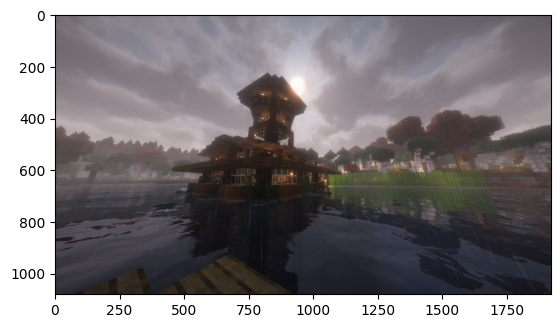

In [6]:
newImg_BGR = imread('base.png')
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)

plt.imshow(newImg_RGB)

## 2. Understanding BINS in Histograms
> Explain the concept of “bins” in the context of image histograms.


Trong histogram "bin" có được xem như là "khoảng" (là phạm vi các giá trị liên tục với nhau). Với histogram trong ảnh thì mỗi bin có thể là các giá trị "khoảng" màu từ 0 -> 255 đối với ảnh RGB, còn với ảnh grayscale là các "khoảng" giá trị cường độ 0 -> 1

vd như là: Cho ảnh có dải giá trị từ 0 đến 255 (8 bit) thì mỗi bin sẽ đại diện cho các giá trị liên tiếp (như là 0-31, 32-63...)

--> Các pixel của ảnh sẽ được "bỏ vô/ gán" vào các bin tuỳ theo giá trị của chúng để dễ trực quan và xử lý hơn


> Describe how bins affect the construction and visualization of histograms

Cấu trúc (Construction):

+ Trục Ox: Ứng với mỗi bin trên trục hoành là một khoảng cường độ (vd ở trên: 0–31, 31–63...)
+ Trục Oy: Thể hiện số lượng pixel thuộc trong mỗi bin (tần suất/cường độ xuất hiện)

Trực quan (Visualization):
+ Số lượng bin (khoảng) ít sẽ gom các giá trị lại thành nhóm lớn, làm biểu đồ trông "thô" nhưng sẽ dễ nhìn hơn. 
+ Số lượng bin (khoảng) nhiều sẽ cho biểu đồ chi tiết hơn, thể hiện rõ các đặc trưng của ảnh nhưng có thể bị "nhiễu"  

Việc chọn số lượng bin phù hợp giúp cân bằng giữa chi tiết và dễ quan sát.​​


## 3. Justification for Using BINS
- Discuss why histograms are divided into bins instead of showing individual pixel intensity values.

Ảnh hiện nay thường có độ phân giải từ hàng trăm nghìn thậm chí hàng triệu pixel (giống như là 1080p, 2k, 4k, 8k.... hiện nay) với mỗi pixel mang giá trị cường độ (0-255 với ảnh xám 8 bit).
Nếu vẽ histogram với từng giá trị riêng lẻ (256 cột) thì histogram sẽ rất chi tiết nhưng dễ bị nhiễu và rối, khi đó việc phân tích tổng thể trở nên phức tạp và khó khăn, nhất là với ảnh màu/ phân giải cao hơn (do càng nhiều màu/ phân giải cao hơn thì càng có nhiều pixel/ dữ liệu cần được giải quyết)
=> So sánh từng giá trị pixel giữa các ảnh sẽ đòi hỏi quá nhiều tài nguyên và xử lý




- Explain how binning influences the accuracy and interpretability of histograms in image analysis.

Khi gộp pixel vào các khoảng (bin) thì lượng thông tin và dữ liệu cần xử lý giảm đáng kể, dễ dàng so sánh histogram giữa các ảnh có cùng cấu hình bin. Việc nhóm dữ liệu vào nhiều bin giúp hình dạng tổng thể của histogram rõ ràng, dễ quan sát xu hướng chính (như là check xem là ảnh có vùng tối, trung tính, hoặc sáng chiếm ưu thế)

Kiểm soát tác động của nhiễu: Bin rộng sẽ làm trơn histogram, giảm tác động của nhiễu; bin hẹp sẽ cho chi tiết cao nhưng dễ bị ảnh hưởng bởi biến động ngẫu nhiên hoặc điểm bất thường.​

Cân bằng độ chính xác và khả năng phân tích:

Quá ít bin (bin rộng): histogram chỉ phản ánh tổng quan, có thể mất những chi tiết quan trọng hoặc các đỉnh nhỏ đặc trưng.

Quá nhiều bin (bin hẹp): histogram quá phân mảnh, khó quan sát xu hướng và dễ bị méo do nhiễu, chi tiết nhỏ lẻ liên tục nhảy cảm.​

Tiện lợi cho tự động và thuật toán phân tích: Khi các ảnh được phân tích cùng một hệ bin chuẩn, việc so sánh, phân loại, tính toán trở nên nhanh chóng hơn rất nhiều so với so sánh từng pixel riêng lẻ hoặc từng tổ hợp màu cụ thể.​